# Linear Regression: Predicting Vancouver Land Value

In [1]:
# Import libraries
import os
import glob
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

# set plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## Load Data

In [2]:
# resolve staging directory relative to this notebook location
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'data', 'staging'))

datasets = {
    'property_tax': 'property_tax_transformed_*.csv',
    'crime': 'crime_transformed_*.csv',
    'business': 'business_licences_transformed_*.csv',
    'local_areas': 'local_areas_transformed_*.csv'
}

def get_latest_file(base_dir, pattern):
    files = glob.glob(os.path.join(base_dir, pattern))
    if not files:
        raise FileNotFoundError(f"Cannot file with this pattern: {pattern}")
    return sorted(files, reverse=True)[0]

data_frames = {}

for key, pattern in datasets.items():
    file_path = get_latest_file(BASE_DIR, pattern)
    low_memory = False if key != 'local_areas' else True
    data_frames[key] = pd.read_csv(file_path, low_memory=low_memory)
    print(f"{key.ljust(13)} : {data_frames[key].shape} (Loaded: {os.path.basename(file_path)})")

property_tax = data_frames['property_tax']
crime = data_frames['crime']
business = data_frames['business']
local_areas = data_frames['local_areas']

property_tax  : (1551157, 26) (Loaded: property_tax_transformed_20260320.csv)
crime         : (875675, 6) (Loaded: crime_transformed_20260320.csv)
business      : (169579, 25) (Loaded: business_licences_transformed_20260320.csv)
local_areas   : (22, 4) (Loaded: local_areas_transformed_20260320.csv)


## Feature Engineering for Crime Rate and Business Density

In [3]:
# standardise neighbourhood names to title-case for consistent joining
crime['neighbourhood']      = crime['neighbourhood'].str.strip().str.title()
business['local_area']      = business['local_area'].str.strip().str.title()
local_areas['name']         = local_areas['name'].str.strip().str.title()

# compute total crime count per neighbourhood 
crime_count = (
    crime
    .groupby('neighbourhood', as_index=False)
    .size()
    .rename(columns={'neighbourhood': 'name', 'size': 'total_crimes'})
)

# compute active business count per neighbourhood 
# keep only active and issued licences to avoid counting expired ones twice
active_business = business[business['status'].str.lower().isin(['issued', 'renewed'])]
business_count = (
    active_business
    .groupby('local_area', as_index=False)
    .size()
    .rename(columns={'local_area': 'name', 'size': 'business_count'})
)

# count total properties per neighbourhood
# use the neighbourhood_code + local_areas mapping
# local_areas only has neighbourhood NAMES
# property_tax only has neighbourhood_code
property_count = (
    property_tax
    .groupby('neighbourhood_code', as_index=False)
    .size()
    .rename(columns={'size': 'property_count'})
)

print('crime_count sample:')
print(crime_count.head())
print('\nbusiness_count sample:')
print(business_count.head())

crime_count sample:
                        name  total_crimes
0              Arbutus Ridge          9435
1  Central Business District        234086
2          Dunbar-Southlands         11570
3                   Fairview         54591
4         Grandview-Woodland         48169

business_count sample:
                 name  business_count
0       Arbutus-Ridge            2189
1            Downtown           38262
2   Dunbar-Southlands            2740
3            Fairview           12778
4  Grandview-Woodland            6936


In [ ]:
# build a neighbourhood lookup table 
# property_tax uses numeric neighbourhood_code 
# crime and business use string names
# local_areas has name but no code -> we will create a code via rank to match
# join crime and business counts onto local_areas by name
# then create neighbourhood_code by sorting local_area names and assigning a rank
# the neighbourhood_code in property_tax runs 1-30 and local_areas has 22 rows
# some codes belong to sub-areas not in local_areas
# merge crime and business counts into local_areas
neighbourhood_features = (
    local_areas[['name']]
    .merge(crime_count,    on='name', how='left')
    .merge(business_count, on='name', how='left')
)
neighbourhood_features['total_crimes']   = neighbourhood_features['total_crimes'].fillna(0)
neighbourhood_features['business_count'] = neighbourhood_features['business_count'].fillna(0)

# map neighbourhood names to property_tax neighbourhood_code 
# property_tax neighbourhood name can be found via the street name or neighbourhood_code
# but there is no direct name column in property_tax
# aggregate property_tax by neighbourhood_code to get median land value
# then join the name-based features using an ordered mapping
# we build the mapping by sorting neighbourhood names alphabetically and
# mapping them to the sorted neighbourhood_codes found in property_tax
unique_codes = sorted(property_tax['neighbourhood_code'].dropna().unique())
unique_names = sorted(neighbourhood_features['name'].unique())

# if counts differ, trim to the shorter list
min_len = min(len(unique_codes), len(unique_names))
code_to_name = dict(zip(unique_codes[:min_len], unique_names[:min_len]))

print(f'Mapping {min_len} neighbourhood codes to names')
print(dict(list(code_to_name.items())[:5]))

Mapping 22 neighbourhood codes to names
{np.int64(1): 'Arbutus Ridge', np.int64(2): 'Downtown', np.int64(3): 'Dunbar-Southlands', np.int64(4): 'Fairview', np.int64(5): 'Grandview-Woodland'}


In [5]:
# aggregate property_tax to neighbourhood level
# take the median land value per neighbourhood_code to reduce skew from outliers
neighbourhood_property = (
    property_tax
    .dropna(subset=['current_land_value', 'zoning_classification'])
    .assign(neighbourhood_code=lambda df: df['neighbourhood_code'].astype(int))
    .groupby('neighbourhood_code', as_index=False)
    .agg(
        median_land_value=('current_land_value', 'median'),
        mean_land_value=('current_land_value', 'mean'),
        property_count=('current_land_value', 'count'),
        top_zoning=('zoning_classification', lambda x: x.mode()[0])
    )
)

# attach neighbourhood name via code_to_name mapping
neighbourhood_property['name'] = neighbourhood_property['neighbourhood_code'].map(code_to_name)

# drop rows where we could not map a name (codes > 22 are sub-areas)
neighbourhood_property = neighbourhood_property.dropna(subset=['name'])

print(f'Neighbourhood-level property table: {neighbourhood_property.shape}')
print(neighbourhood_property.head())

Neighbourhood-level property table: (22, 6)
   neighbourhood_code  median_land_value  mean_land_value  property_count  \
0                   1          2591000.0     3.585661e+06           30553   
1                   2          1012000.0     1.752867e+06          104879   
2                   3          2530000.0     2.763640e+06           34633   
3                   4          2648000.0     2.865171e+06           28199   
4                   5          2391000.0     2.502808e+06           30520   

              top_zoning                name  
0  Residential Inclusive       Arbutus Ridge  
1            Residential            Downtown  
2  Residential Inclusive   Dunbar-Southlands  
3  Residential Inclusive            Fairview  
4  Residential Inclusive  Grandview-Woodland  


In [6]:
# join crime and business features onto neighbourhood property table
neighbourhood_ml = neighbourhood_property.merge(
    neighbourhood_features[['name', 'total_crimes', 'business_count']],
    on='name',
    how='left'
)

# compute crime_rate: crimes per 1000 properties
neighbourhood_ml['crime_rate'] = (
    neighbourhood_ml['total_crimes'] / neighbourhood_ml['property_count'] * 1000
)

# compute business_density: businesses per 1000 properties
neighbourhood_ml['business_density'] = (
    neighbourhood_ml['business_count'] / neighbourhood_ml['property_count'] * 1000
)

print(f'Final neighbourhood ML table: {neighbourhood_ml.shape}')
print(neighbourhood_ml[['name', 'median_land_value', 'crime_rate', 'business_density', 'top_zoning']].to_string())

Final neighbourhood ML table: (22, 10)
                        name  median_land_value   crime_rate  business_density                 top_zoning
0              Arbutus Ridge          2591000.0   308.807646          0.000000      Residential Inclusive
1                   Downtown          1012000.0     0.000000        364.820412                Residential
2          Dunbar-Southlands          2530000.0   334.074438         79.115295      Residential Inclusive
3                   Fairview          2648000.0  1935.919713        453.136636      Residential Inclusive
4         Grandview-Woodland          2391000.0  1578.276540        227.260813      Residential Inclusive
5           Hastings-Sunrise          2817000.0  1994.399420        356.065099      Residential Inclusive
6   Kensington-Cedar Cottage           681000.0   447.113075         90.498607  Comprehensive Development
7                 Kerrisdale          3831000.0   665.132663        123.572524      Residential Inclusive
8      

## Property Level Dataset for Regression

We work at the **property level** (each row = one property) to give the model enough observations.
Crime rate and business density are neighbourhood level features joined onto each property.

In [7]:
# prepare property-level dataframe 
df = (
    property_tax
    .dropna(subset=['current_land_value', 'zoning_classification'])
    .assign(neighbourhood_code=lambda d: d['neighbourhood_code'].astype(int))
    .copy()
)

# map neighbourhood name
df['name'] = df['neighbourhood_code'].map(code_to_name)
df = df.dropna(subset=['name'])

# join crime_rate and business_density from neighbourhood level features
df = df.merge(
    neighbourhood_ml[['name', 'crime_rate', 'business_density']],
    on='name',
    how='left'
)

# drop rows with missing engineered features
df = df.dropna(subset=['crime_rate', 'business_density'])

print(f'Property-level dataset for regression: {df.shape}')
print(df[['current_land_value', 'zoning_classification', 'crime_rate', 'business_density']].describe())

Property-level dataset for regression: (989895, 29)
       current_land_value     crime_rate  business_density
count        9.898950e+05  989895.000000     989895.000000
mean         1.958880e+06     641.211442        149.074397
std          6.973788e+06     654.746437        133.371344
min          0.000000e+00       0.000000          0.000000
25%          6.210000e+05     180.085414         38.734897
50%          1.318000e+06     447.113075         95.763911
75%          2.044000e+06     816.801732        227.260813
max          1.071562e+09    2691.472439        480.596351


In [8]:
# remove extreme outliers in target variable 
upper_cap = df['current_land_value'].quantile(0.99)
lower_cap = df['current_land_value'].quantile(0.01)
df = df[(df['current_land_value'] >= lower_cap) & (df['current_land_value'] <= upper_cap)]

print(f'After outlier removal: {df.shape}')
print(f'Land value range: ${df["current_land_value"].min():,.0f} – ${df["current_land_value"].max():,.0f}')

After outlier removal: (970133, 29)
Land value range: $204,000 – $12,897,000


In [9]:
# encode zoning_classification (label encoding)
# label encoding preserves ordinality assumption; we note this in interpretation
le = LabelEncoder()
df['zoning_encoded'] = le.fit_transform(df['zoning_classification'])

zoning_map = dict(zip(le.classes_, le.transform(le.classes_)))
print('Zoning label encoding:')
for k, v in zoning_map.items():
    print(f'  {v} -> {k}')

Zoning label encoding:
  0 -> Commercial
  1 -> Comprehensive Development
  2 -> Industrial
  3 -> Limited Agriculture
  4 -> Multiple Dwelling
  5 -> One-Family Dwelling
  6 -> Other
  7 -> Residential
  8 -> Residential Inclusive
  9 -> Residential Rental
  10 -> Two-Family Dwelling


## Correlation Analysis

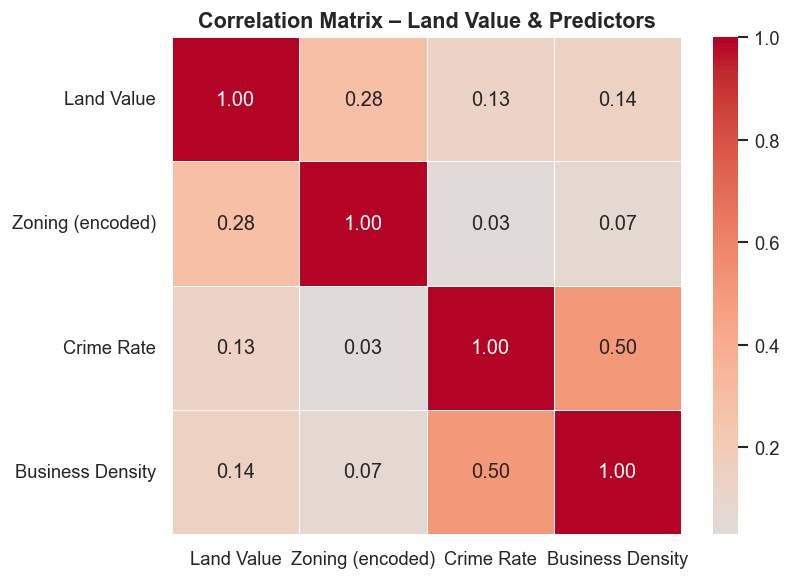

In [10]:
# correlation heatmap between features and target
corr_df = df[['current_land_value', 'zoning_encoded', 'crime_rate', 'business_density']].copy()
corr_df.columns = ['Land Value', 'Zoning (encoded)', 'Crime Rate', 'Business Density']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    linewidths=0.5
)
ax.set_title('Correlation Matrix – Land Value & Predictors', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Model Training

In [11]:
# define features and target
FEATURES = ['zoning_encoded', 'crime_rate', 'business_density']
TARGET   = 'current_land_value'

X = df[FEATURES].values
y = df[TARGET].values

# 80/20 train-test split with fixed random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scale features using StandardScaler for interpretable coefficients
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# fit linear regression model
model = LinearRegression()
model.fit(X_train_sc, y_train)

print('Model trained successfully')
print(f'Train samples : {X_train.shape[0]:,}')
print(f'Test  samples : {X_test.shape[0]:,}')

Model trained successfully
Train samples : 776,106
Test  samples : 194,027


## Model Evaluation

In [12]:
# generate predictions on the test set
y_pred = model.predict(X_test_sc)

# compute evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print('MODEL EVALUATION METRICS')
print(f'R² Score: {r2:.4f}')
print(f'RMSE    : ${rmse:,.0f}')
print(f'MAE     : ${mae:,.0f}')

MODEL EVALUATION METRICS
R² Score: 0.0990
RMSE    : $1,309,987
MAE     : $793,910


In [13]:
# coefficients are in standardised scale (per 1 std dev change in feature)
coef_df = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coefficient': model.coef_
})

# also compute raw coefficients for direct interpretation
# raw_coef = standardised_coef / std(feature)
feature_stds = scaler.scale_
coef_df['Raw Coefficient (per unit)'] = model.coef_ / feature_stds

print('Coefficient Table (standardised and raw):')
print(coef_df.to_string(index=False))
print()

# key finding: crime rate impact
crime_raw_coef = coef_df.loc[coef_df['Feature'] == 'crime_rate', 'Raw Coefficient (per unit)'].values[0]
print(f'KEY FINDING: Each additional crime per 1,000 properties is associated with a')
print(f'${crime_raw_coef:,.0f} change in land value (negative = decrease)')

Coefficient Table (standardised and raw):
         Feature   Coefficient  Raw Coefficient (per unit)
  zoning_encoded 375244.911269               119148.949436
      crime_rate 112390.229196                  172.475428
business_density 114773.879348                  859.401004

KEY FINDING: Each additional crime per 1,000 properties is associated with a
$172 change in land value (negative = decrease)


## Visualizations

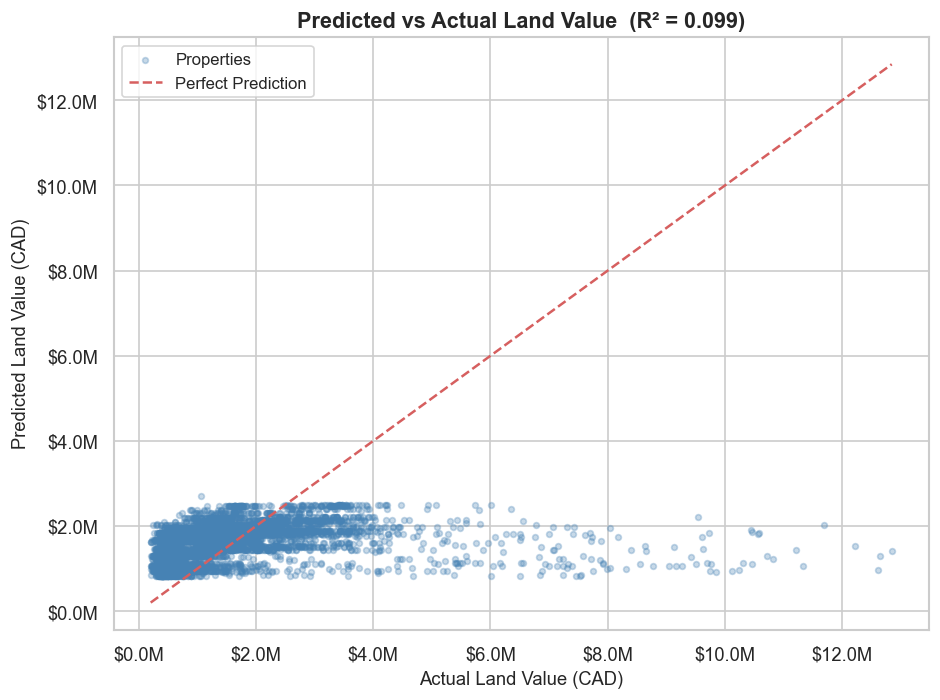

In [14]:
# Predicted vs Actual scatter plot
# sample 5000 points for performance
sample_idx  = np.random.choice(len(y_test), size=min(5000, len(y_test)), replace=False)
y_test_s    = y_test[sample_idx]
y_pred_s    = y_pred[sample_idx]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test_s, y_pred_s, alpha=0.3, s=12, color='steelblue', label='Properties')

# perfect prediction line
lims = [min(y_test_s.min(), y_pred_s.min()), max(y_test_s.max(), y_pred_s.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')

ax.set_xlabel('Actual Land Value (CAD)', fontsize=11)
ax.set_ylabel('Predicted Land Value (CAD)', fontsize=11)
ax.set_title(f'Predicted vs Actual Land Value  (R² = {r2:.3f})', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

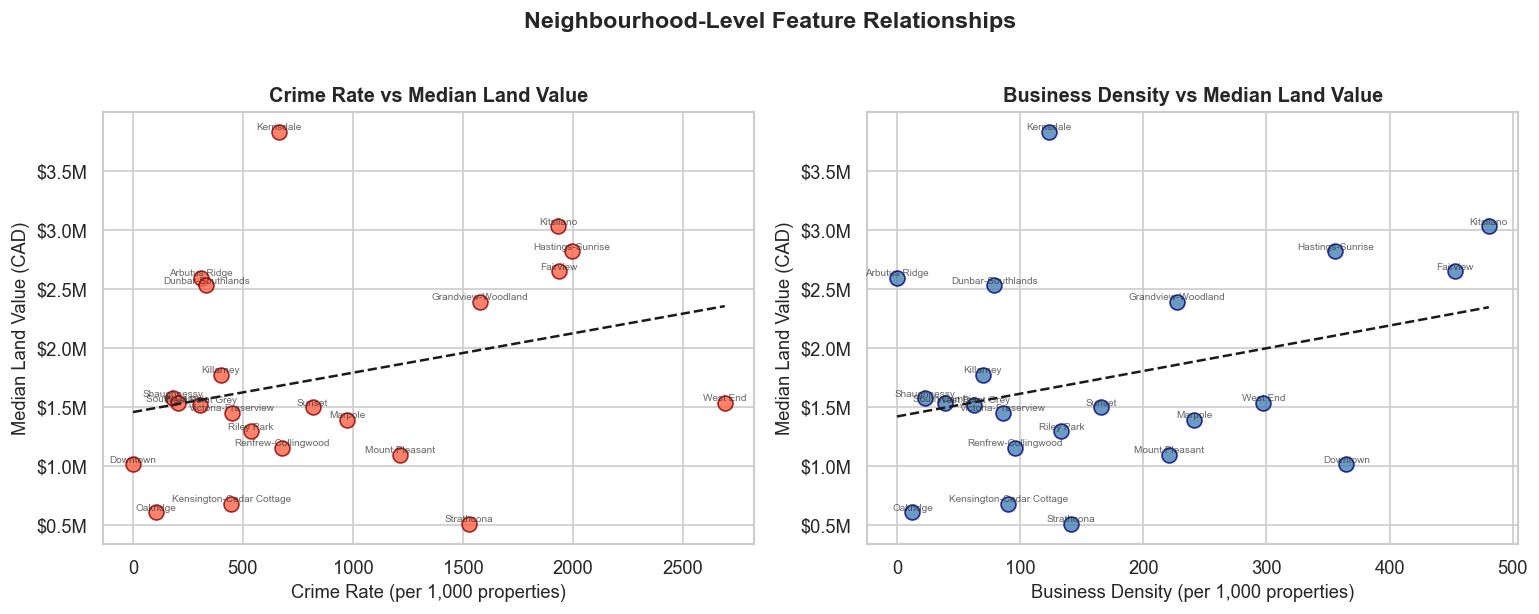

In [15]:
# Crime Rate vs Median Land Value
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Crime Rate vs Land Value
ax = axes[0]
ax.scatter(
    neighbourhood_ml['crime_rate'],
    neighbourhood_ml['median_land_value'],
    s=80, color='tomato', edgecolors='darkred', alpha=0.8
)
# fit a trend line
m, b = np.polyfit(neighbourhood_ml['crime_rate'].fillna(0),
                   neighbourhood_ml['median_land_value'].fillna(0), 1)
x_line = np.linspace(neighbourhood_ml['crime_rate'].min(), neighbourhood_ml['crime_rate'].max(), 100)
ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.5)
for _, row in neighbourhood_ml.iterrows():
    ax.annotate(row['name'], (row['crime_rate'], row['median_land_value']),
                fontsize=6, alpha=0.7, ha='center', va='bottom')
ax.set_xlabel('Crime Rate (per 1,000 properties)', fontsize=11)
ax.set_ylabel('Median Land Value (CAD)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Crime Rate vs Median Land Value', fontsize=12, fontweight='bold')

# Business Density vs Land Value
ax = axes[1]
ax.scatter(
    neighbourhood_ml['business_density'],
    neighbourhood_ml['median_land_value'],
    s=80, color='steelblue', edgecolors='navy', alpha=0.8
)
m2, b2 = np.polyfit(neighbourhood_ml['business_density'].fillna(0),
                     neighbourhood_ml['median_land_value'].fillna(0), 1)
x_line2 = np.linspace(neighbourhood_ml['business_density'].min(), neighbourhood_ml['business_density'].max(), 100)
ax.plot(x_line2, m2 * x_line2 + b2, 'k--', linewidth=1.5)
for _, row in neighbourhood_ml.iterrows():
    ax.annotate(row['name'], (row['business_density'], row['median_land_value']),
                fontsize=6, alpha=0.7, ha='center', va='bottom')
ax.set_xlabel('Business Density (per 1,000 properties)', fontsize=11)
ax.set_ylabel('Median Land Value (CAD)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Business Density vs Median Land Value', fontsize=12, fontweight='bold')

plt.suptitle('Neighbourhood-Level Feature Relationships', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Summary and Key Findings

In [16]:
# final summary printout for verification
print('MULTIPLE LINEAR REGRESSION SUMMARY')
print(f'Target variable  : current_land_value (CAD)')
print(f'Training samples : {X_train.shape[0]:,}')
print(f'Test samples     : {X_test.shape[0]:,}')
print(f'R² Score         : {r2:.4f}')
print(f'RMSE             : ${rmse:,.0f}')
print(f'MAE              : ${mae:,.0f}')
print()
print('Coefficient Interpretation (raw, per-unit):')
for _, row in coef_df.iterrows():
    direction = 'increase' if row['Raw Coefficient (per unit)'] > 0 else 'decrease'
    print(f"  - {row['Feature']:20s}: 1 unit increase -> ${abs(row['Raw Coefficient (per unit)']):,.0f} {direction} in land value")

MULTIPLE LINEAR REGRESSION SUMMARY
Target variable  : current_land_value (CAD)
Training samples : 776,106
Test samples     : 194,027
R² Score         : 0.0990
RMSE             : $1,309,987
MAE              : $793,910

Coefficient Interpretation (raw, per-unit):
  - zoning_encoded      : 1 unit increase -> $119,149 increase in land value
  - crime_rate          : 1 unit increase -> $172 increase in land value
  - business_density    : 1 unit increase -> $859 increase in land value
